In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = sns.load_dataset("titanic")

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


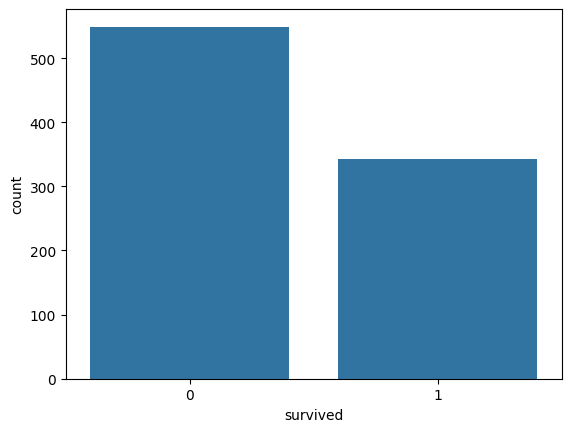

In [ ]:
sns.countplot(x="survived", data=df)
plt.show()


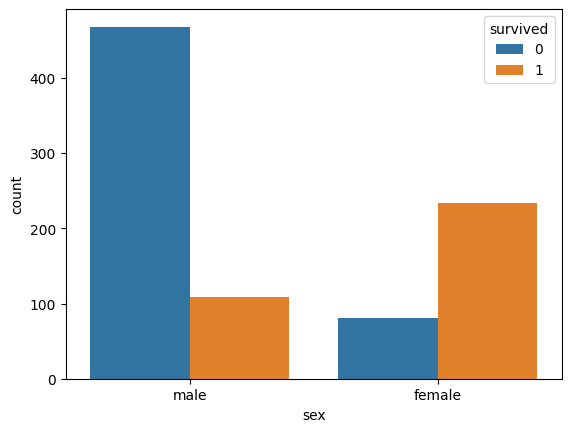

In [ ]:
sns.countplot(x="sex", hue="survived", data=df)
plt.show()

In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]

X = df[features].copy()
y = df["survived"]


In [ ]:
X["age"] = X["age"].fillna(X["age"].median())

In [ ]:
X.isnull().sum()

,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2


In [ ]:
X["embarked"] = X["embarked"].fillna(X["embarked"].mode()[0])

In [ ]:
X.isnull().sum()

,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 7)
Testing data: (179, 7)


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train[["sex", "embarked"]])
X_test_encoded = encoder.transform(X_test[["sex", "embarked"]])

In [ ]:
import numpy as np

# Numerical columns
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]

X_train_numeric = X_train[numeric_features].values
X_test_numeric = X_test[numeric_features].values

# Combine numerical and encoded categorical columns
X_train_final = np.hstack((X_train_numeric, X_train_encoded))
X_test_final = np.hstack((X_test_numeric, X_test_encoded))

# Check the result
print("Training shape:", X_train_final.shape)
print("Testing shape:", X_test_final.shape)

Training shape: (712, 10)
Testing shape: (179, 10)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the model
model_lr = LogisticRegression(max_iter=1000)

# Train the model
model_lr.fit(X_train_final, y_train)

# Make predictions on test data
y_pred_lr = model_lr.predict(X_test_final)

# Show first 20 predictions
print(y_pred_lr[:20])


[0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Logistic Regression Results
Accuracy : 0.8044692737430168
Precision: 0.7931034482758621
Recall   : 0.6666666666666666
F1 Score : 0.7244094488188977


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
model_rf.fit(X_train_final, y_train)

# Make predictions
y_pred_rf = model_rf.predict(X_test_final)

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)


Random Forest Results
Accuracy : 0.8212290502793296
Precision: 0.8135593220338984
Recall   : 0.6956521739130435
F1 Score : 0.75


In [33]:
train_pred_lr = model_lr.predict(X_train_final)
test_pred_lr = model_lr.predict(X_test_final)

train_accuracy_lr = accuracy_score(y_train, train_pred_lr)
test_accuracy_lr = accuracy_score(y_test, test_pred_lr)


# Random Forest

train_pred_rf = model_rf.predict(X_train_final)
test_accuracy_rf = accuracy_score(y_test, y_pred_rf)

train_accuracy_rf = accuracy_score(y_train, train_pred_rf)


print("Logistic Regression")
print("Training Accuracy:", train_accuracy_lr)
print("Testing Accuracy :", test_accuracy_lr)

print("\nRandom Forest")
print("Training Accuracy:", train_accuracy_rf)
print("Testing Accuracy :", test_accuracy_rf)

Logistic Regression
Training Accuracy: 0.8075842696629213
Testing Accuracy : 0.8044692737430168

Random Forest
Training Accuracy: 0.9817415730337079
Testing Accuracy : 0.8212290502793296


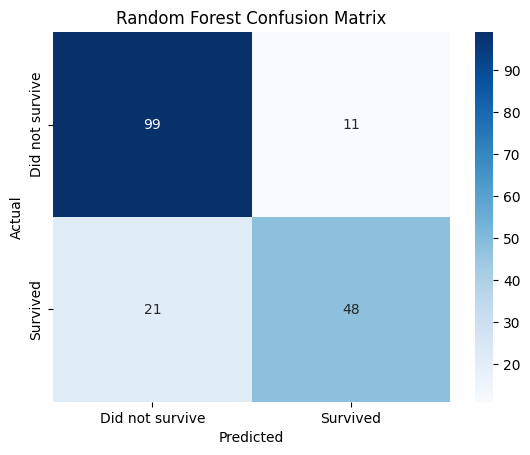

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did not survive", "Survived"],
    yticklabels=["Did not survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
# Find incorrect predictions
wrong_predictions = X_test[y_test != y_pred_rf].copy()

# Add actual and predicted values
wrong_predictions["actual"] = y_test[y_test != y_pred_rf]
wrong_predictions["predicted"] = y_pred_rf[y_test != y_pred_rf]

# Display the first wrong prediction
wrong_predictions.head(1)


,pclass,sex,age,sibsp,parch,fare,embarked,actual,predicted
553,3,male,22.0,0,0,7.225,C,1,0


In [34]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, accuracy_rf],
    "Precision": [precision, precision_rf],
    "Recall": [recall, recall_rf],
    "F1 Score": [f1, f1_rf],
    "Training Accuracy": [train_accuracy_lr, train_accuracy_rf],
    "Testing Accuracy": [test_accuracy_lr, test_accuracy_rf]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,Training Accuracy,Testing Accuracy
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.807584,0.804469
1,Random Forest,0.821229,0.813559,0.695652,0.750000,0.981742,0.821229


## Model Comparison and Conclusion

Two classification models were trained and evaluated: Logistic Regression and Random Forest.

### Results

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| Logistic Regression | 80.45% | 79.31% | 66.67% | 72.44% |
| Random Forest | 82.12% | 81.36% | 69.57% | 75.00% |

Random Forest achieved higher performance on all four test metrics. However, its training accuracy was 98.17%, while its testing accuracy was 82.12%, showing a substantial train-test gap and evidence of overfitting.

Logistic Regression had a much smaller gap between training accuracy (80.76%) and testing accuracy (80.45%), indicating more consistent performance between training and unseen data.

For this project, Random Forest can be considered the higher-performing model on the test set, while Logistic Regression provides a simpler model with much less evidence of overfitting. The final choice depends on whether higher test performance or a smaller train-test gap is prioritized.

# Project Summary

## Problem Statement

The goal of this project is to predict whether a passenger survived the Titanic disaster using passenger information such as class, sex, age, fare, and embarkation point.

## Approach

1. Loaded the Titanic dataset.
2. Performed exploratory data analysis (EDA).
3. Identified and handled missing values.
4. Selected relevant features.
5. Split the data into training and testing sets.
6. Encoded categorical features using One-Hot Encoding.
7. Trained Logistic Regression and Random Forest models.
8. Evaluated both models using Accuracy, Precision, Recall, and F1 Score.
9. Compared training and testing accuracy to identify overfitting.
10. Examined incorrect predictions using a confusion matrix and an example error.

## Results

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| Logistic Regression | 80.45% | 79.31% | 66.67% | 72.44% |
| Random Forest | 82.12% | 81.36% | 69.57% | 75.00% |

Random Forest achieved higher test-set values for all four evaluation metrics. However, its training accuracy was 98.17% compared with a testing accuracy of 82.12%, showing a substantial train-test gap.

Logistic Regression had a much smaller gap between training accuracy (80.76%) and testing accuracy (80.45%).

## Example of a Wrong Prediction

One example was passenger 553.

- Actual outcome: Survived
- Model prediction: Did not survive
- Age: 22
- Sex: Male
- Passenger class: 3
- Fare: 7.225

This demonstrates that even a model with good overall performance can make individual incorrect predictions.

## Limitation

This project uses a single train-test split and a relatively small set of passenger features. In a more rigorous version, preprocessing could be placed inside a machine-learning pipeline so that values such as imputation are learned only from the training data.

## Learnings

- Learned the basic workflow of an end-to-end machine learning project.
- Learned how to perform exploratory data analysis using Pandas, Matplotlib, and Seaborn.
- Learned how to handle missing values.
- Learned how categorical data can be converted into numerical features using One-Hot Encoding.
- Learned the difference between training and testing data.
- Learned how Logistic Regression can be used for classification.
- Learned how Random Forest combines multiple decision trees.
- Learned how Accuracy, Precision, Recall, and F1 Score evaluate a classification model.
- Learned how to identify overfitting using the training-testing performance gap.
- Learned that machine learning models can still make incorrect predictions even when their overall metrics are good.